In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, FormatStrFormatter
import pickle

from pbhstat.power_spectrum import PowerSpectrum
from pbhstat.mass_variance import MassVariance
from pbhstat.collapse_stats import PressSchechterModel, PeaksTheoryModel, NonLinearModel
from pbhstat.mass_function import MassFunction
from pbhstat.plot_utils import plot_power_spectrum, plot_mass_variance, plot_mass_function, bounds_utility

In [2]:
# Set up k values
k_values = np.logspace(5, 7, 3000)

# Custom power spectrum 
Ak = 0.018
Deltak = 0.3
kpeak = 1e6 #Units of Mpc-1
P_k_custom = Ak * np.exp(-0.5 * (1/(np.sqrt(2 * np.pi) * Deltak)) * (np.log(k_values / kpeak) / Deltak)**2)  # log-normal bump

# alternatively load array of P_k_values corresponding to k_values
# with open("path_to_P_k_array.pickle", "rb") as f:
#     P_k_custom = pickle.load(f)

# Instantiate power spectrum
ps_custom = PowerSpectrum(
    shape='custom',
    k_values=k_values,
    P_k_values=P_k_custom
)

# Instantiate mass variance with choice of window function and statistics
mv_custom = MassVariance(window='realtophat', power_spectrum=ps_custom, statistics='press', cutoff=True)

# Instantiate mass function with same statistics model
mass_function = MassFunction(mass_variance=mv_custom, statistics='press', K=4, g_c=0.77, gamma=0.36)

In [3]:
# Evaluate f(M) and f_PBH
m, f_m = mass_function.evaluate(k_values, mpbh_vals=50)

fpbh = mass_function.fpbh(f_m, m)
print(fpbh)

0.23428598733188258


In [9]:
bounds_utility(m, f_m, '/Documents/PBHbounds/')

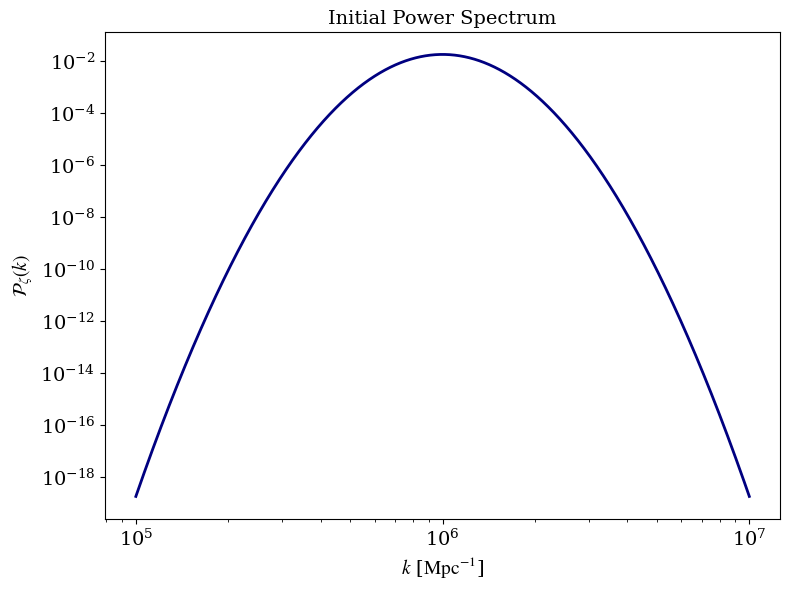

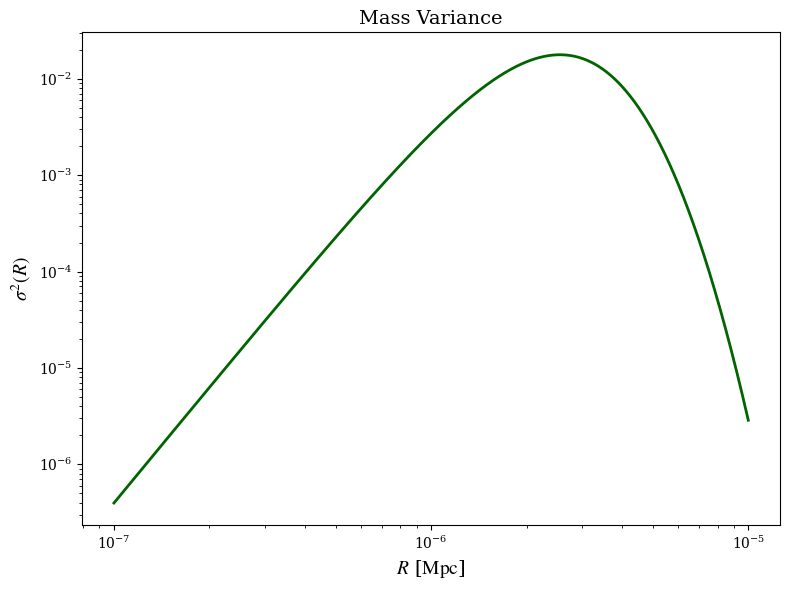

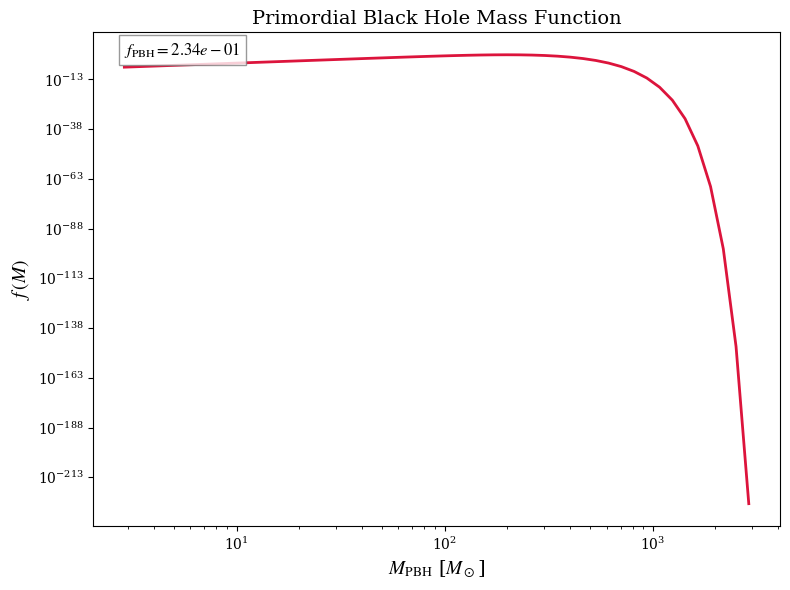

In [4]:
# Plot power spectrum

plot_power_spectrum(k_values, P_k_custom)

# Plot mass variance

# Define R values
R_values = 1/k_values

# Evaluate mass variance at k_values
sigma_custom = mv_custom.evaluate(k_values)

plot_mass_variance(R_values, sigma_custom)

# Plot mass function

plot_mass_function(m, f_m, fpbh_val=fpbh)